In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [18]:
len(df)

541909

## FINDING MISSING VALUES

In [19]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [20]:
# MISSING VALUE REPORT

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum())/ len(df) * 100
missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage.round(2)
}) # combining into a missing report dataframe

missing_report = missing_report[missing_report['Missing Values']> 0].sort_values(by = 'Missing Values', ascending = False)
missing_report

,Missing Values,Percentage (%)
CustomerID,135080,24.93
Description,1454,0.27


## DUPLICATES CHECK

In [22]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.count()

,0
InvoiceNo,5268
StockCode,5268
Description,5268
Quantity,5268
InvoiceDate,5268
UnitPrice,5268
CustomerID,5225
Country,5268


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## OUTLIERS CHECK

In [24]:
# OUTLIER Report USING IQR METHOD
# FOR QUANTITY AND UNITPRICE

metrics = ['Quantity', 'UnitPrice']
outlier_summary = []

for col in metrics:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    total_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    pct_outliers = (total_outliers / len(df)) * 100

    outlier_summary.append({
        'Metric': col,
        'Q1 (25th)': Q1,
        'Q3 (75th)': Q3,
        'Q2 (IQR)': IQR,
        'Upper Bound': upper_bound,
        'Outlier Count': total_outliers,
        'Percentage (%)': round(pct_outliers, 2)
    })

# Display Report
outlier_report = pd.DataFrame(outlier_summary)
print("--- Statistical Outlier Report ---")
print(outlier_report.to_string(index=False))

--- Statistical Outlier Report ---
   Metric  Q1 (25th)  Q3 (75th)  Q2 (IQR)  Upper Bound  Outlier Count  Percentage (%)
 Quantity       1.00      10.00      9.00        23.50          58619           10.82
UnitPrice       1.25       4.13      2.88         8.45          39627            7.31


In [25]:
df[df["Quantity"]<0].count()

,0
InvoiceNo,10624
StockCode,10624
Description,9762
Quantity,10624
InvoiceDate,10624
UnitPrice,10624
CustomerID,8905
Country,10624


## CLEANED DATASET

In [26]:
df_cleaned = df.drop_duplicates().copy()
# Converting column customer id from FLOAT to INTEGER
df_cleaned.dropna(subset=['CustomerID'], inplace=True)
df_cleaned['CustomerID'] = df_cleaned['CustomerID'].astype(int)
print(df_cleaned['CustomerID'].dtype)
print(f"\nTotal rows after removing missing CustID: {len(df_cleaned)}")
print(df_cleaned.head())

int64

Total rows after removing missing CustID: 401604
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom  
4 2010-12-01 08:26:00       3.39       17850  United Kingdom  


In [27]:
print('Total Duplicates & Missing Value Dropped: ', len(df) - len(df_cleaned))

Total Duplicates & Missing Value Dropped:  140305


In [28]:
# imputation for 'description' missing values

df_cleaned['Description'] = df_cleaned['Description'].fillna('UNKNOWN ITEM')

In [29]:
# REVENUE
df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

In [30]:
# Filter rows where UnitPrice is 0
zero_price_items = df_cleaned[df_cleaned['UnitPrice'] == 0]

print(f"Number of transactions with UnitPrice = 0: {len(zero_price_items)}")
print("\nSample of transactions with UnitPrice = 0:")
display(zero_price_items.head())

# Calculate their total revenue contribution (should be 0, but good to confirm)
total_revenue_from_zero_price = zero_price_items['Revenue'].sum()
print(f"\nTotal Revenue from items with UnitPrice = 0: £{total_revenue_from_zero_price:.2f}")

if len(zero_price_items) > 0:
    initial_rows_with_zero_price = len(df_cleaned)
    df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0].copy()
    rows_removed = initial_rows_with_zero_price - len(df_cleaned)
    print(f"\nRemoved {rows_removed} rows where UnitPrice was 0.")
    print(f"New number of rows in df_cleaned: {len(df_cleaned)}")
else:
    print("No transactions found with UnitPrice = 0. No action needed.")

Number of transactions with UnitPrice = 0: 40

Sample of transactions with UnitPrice = 0:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany,0.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom,0.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE,0.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0



Total Revenue from items with UnitPrice = 0: £0.00

Removed 40 rows where UnitPrice was 0.
New number of rows in df_cleaned: 401564


In [31]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

In [32]:
# Apply IQR-based outlier removal for 'Quantity' and 'UnitPrice'
# For Quantity:
Q1_qty = df_cleaned['Quantity'].quantile(0.25)
Q3_qty = df_cleaned['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
upper_qty = Q3_qty + 1.5 * IQR_qty
lower_qty = Q1_qty - 1.5 * IQR_qty

# For UnitPrice:
Q1_price = df_cleaned['UnitPrice'].quantile(0.25)
Q3_price = df_cleaned['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_price = Q3_price + 1.5 * IQR_price
lower_price = Q1_price - 1.5 * IQR_price

df_cleaned = df_cleaned[
    (df_cleaned['Quantity'] >= lower_qty) & (df_cleaned['Quantity'] <= upper_qty) &
    (df_cleaned['UnitPrice'] >= lower_price) & (df_cleaned['UnitPrice'] <= upper_price)
].copy()

In [33]:
print(f"\nTotal rows kept BEFORE CLEANING: {len(df)}")
# Verify the changes
print("--- Imputed & Cleaned Dataset ---")
print(df_cleaned.isnull().sum())
print(f"\nTotal rows kept AFTER CLEANING: {len(df_cleaned)}")


Total rows kept BEFORE CLEANING: 541909
--- Imputed & Cleaned Dataset ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Total rows kept AFTER CLEANING: 339422


In [34]:
print(f"Minimum UnitPrice after cleaning: {df_cleaned['UnitPrice'].min()}")

Minimum UnitPrice after cleaning: 0.001


## BASIC SUMMARY STATISTICS

In [35]:
# Create a flag for returns and calculate Gross Revenue
df_cleaned['IsReturn'] = df_cleaned['Quantity'] < 0

# For analyses requiring only positive sales, you can use GrossRevenue
df_cleaned['GrossRevenue'] = df_cleaned['Revenue'].apply(lambda x: x if x > 0 else 0)

print("Added 'IsReturn' column to flag cancelled transactions.")
print("Added 'GrossRevenue' column for positive sales analysis.")
display(df_cleaned.head())

Added 'IsReturn' column to flag cancelled transactions.
Added 'GrossRevenue' column for positive sales analysis.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsReturn,GrossRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,False,20.34


In [36]:
df_cleaned.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,GrossRevenue
count,339422.000000,339422,339422.000000,339422.000000,339422.000000,339422.000000
mean,7.350116,2011-07-12 07:30:26.866556160,2.203661,15312.698991,12.523229,12.667052
min,-13.000000,2010-12-01 08:26:00,0.001000,12347.000000,-81.000000,0.000000
25%,2.000000,2011-04-08 08:21:00,1.250000,13983.000000,3.750000,3.750000
50%,6.000000,2011-08-03 09:09:00,1.650000,15218.000000,10.080000,10.080000
75%,12.000000,2011-10-21 14:29:00,2.950000,16813.000000,17.340000,17.340000
max,27.000000,2011-12-09 12:50:00,7.500000,18287.000000,178.800000,178.800000
std,6.890296,NaN,1.549604,1711.876237,13.433035,13.207238


In [37]:
from google.colab import files
df_cleaned.to_csv('Cleaned_Online_Retails.csv', index=False)
# files.download('Cleaned_Online_Retails.csv')

# WEEK 2

In [38]:
# Check the date range of the dataset
start_date = df_cleaned['InvoiceDate'].min()
end_date = df_cleaned['InvoiceDate'].max()

print(f"Dataset Starts on: {start_date}")
print(f"Dataset Ends on:   {end_date}")
print(f"Total Duration:    {end_date - start_date}")

Dataset Starts on: 2010-12-01 08:26:00
Dataset Ends on:   2011-12-09 12:50:00
Total Duration:    373 days 04:24:00


# REVENUE TRENDS

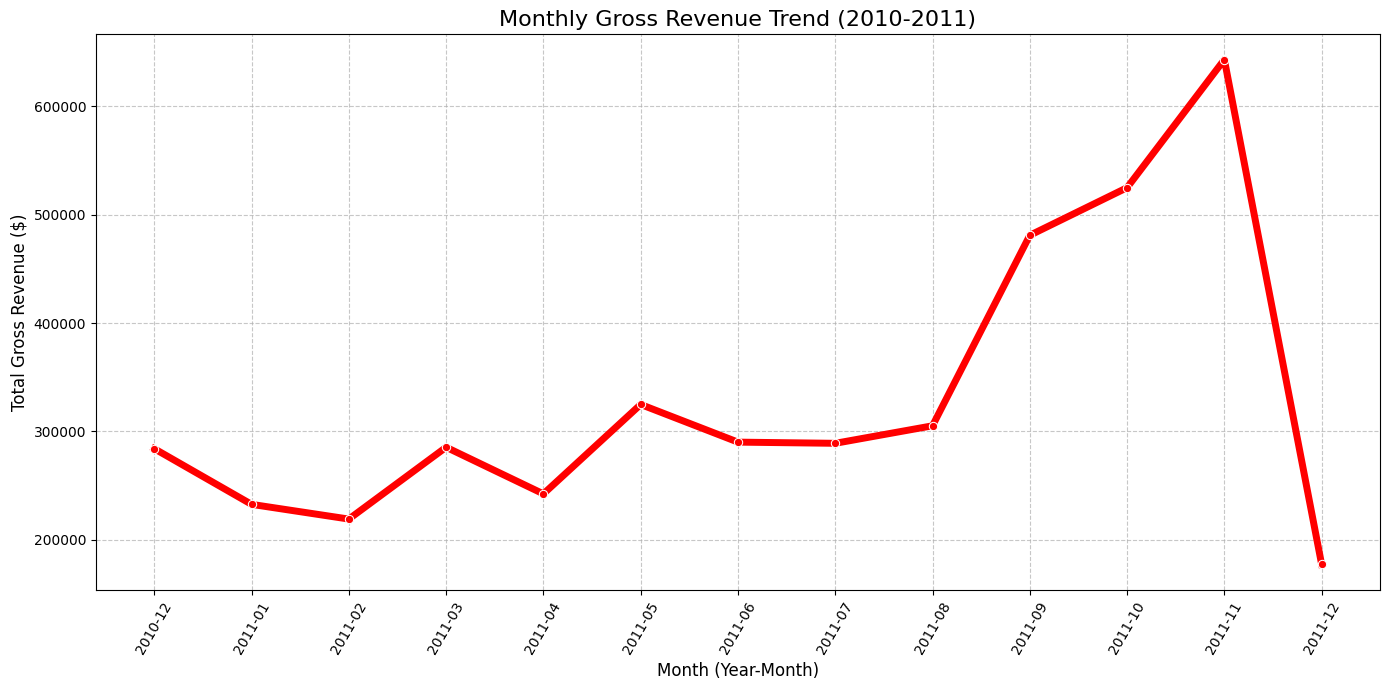

In [39]:

# MONTHLY

# Ensure Revenue is correctly calculated, though GrossRevenue will be used for plotting
df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
df_cleaned['YearMonth'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Group by YearMonth and sum GrossRevenue
monthly_gross_revenue = df_cleaned.groupby(
    df_cleaned['InvoiceDate'].dt.to_period('M')
)['GrossRevenue'].sum()

plt.figure(figsize=(14, 7))
sns.lineplot(
    x=monthly_gross_revenue.index.astype(str),
    y=monthly_gross_revenue.values,
    marker='o',
    color='red',
    linestyle='-',
    linewidth=5
)
plt.title('Monthly Gross Revenue Trend (2010-2011)', fontsize=16)
plt.xlabel('Month (Year-Month)', fontsize=12)
plt.ylabel('Total Gross Revenue ($)', fontsize=12)
plt.xticks(rotation=60)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300)
plt.show()

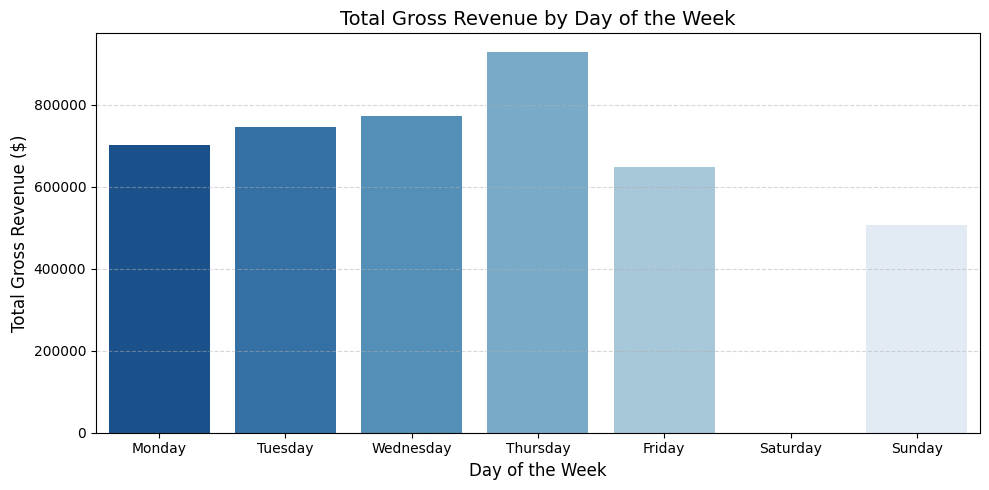

In [40]:
# DAYS OF WEEKDAYS

# Extract the day name from InvoiceDate
df_cleaned['DayOfWeek'] = df_cleaned['InvoiceDate'].dt.day_name()

# Sort weekdays chronologically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_gross_revenue = df_cleaned.groupby('DayOfWeek')['GrossRevenue'].sum().reindex(day_order).reset_index()

# Plot
plt.figure(figsize=(10, 5))
# sns.lineplot(x='DayOfWeek', y='GrossRevenue', data=daily_gross_revenue, marker='o', color='darkblue')
sns.barplot(x='DayOfWeek', y='GrossRevenue', data=daily_gross_revenue, palette='Blues_r', hue='DayOfWeek', legend=False)
plt.title('Total Gross Revenue by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Gross Revenue ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## CUSTOMER TRENDS

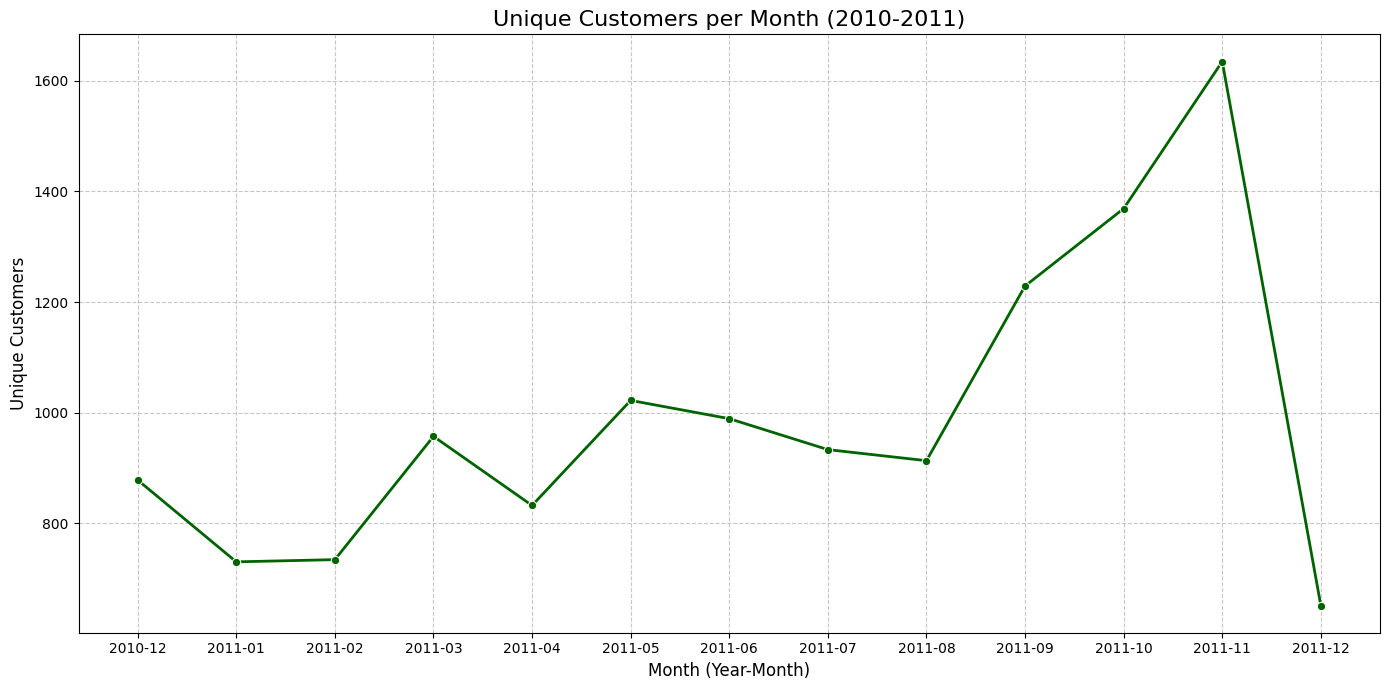

In [41]:
# Calculate unique customers per month
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
customer_monthly = df_cleaned.groupby(df_cleaned['InvoiceDate'].dt.to_period('M'))['CustomerID'].nunique()

plt.figure(figsize=(14, 7))
sns.lineplot(x=customer_monthly.index.astype(str), y=customer_monthly.values, marker='o', color='darkgreen', linestyle='-', linewidth=2)
plt.title('Unique Customers per Month (2010-2011)', fontsize=16)
plt.xlabel('Month (Year-Month)', fontsize=12)
plt.ylabel('Unique Customers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# PRODUCT TRENDS

### Top 10 Products

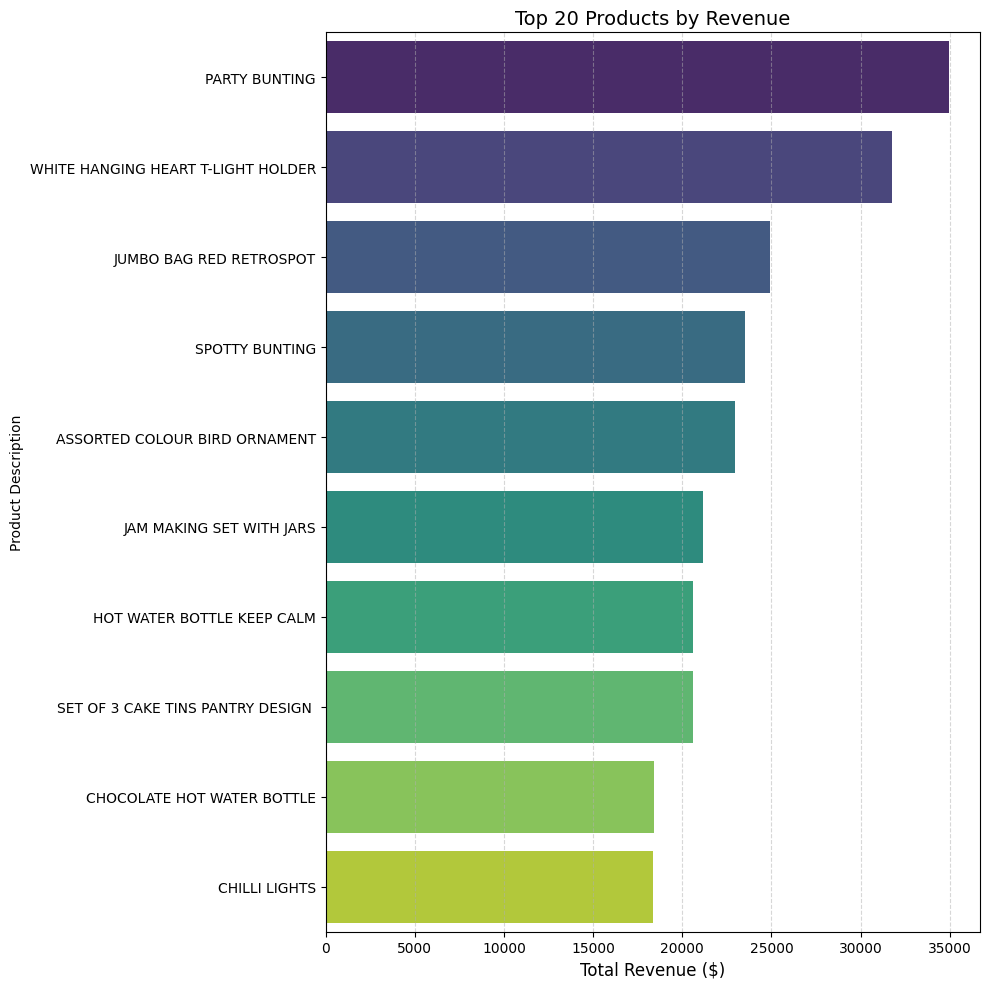

In [42]:
#  Top 20 Products by Revenue

top_products = (
    df_cleaned.groupby('Description')['GrossRevenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Horizontal Bar plt
plt.figure(figsize=(10, 10))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis', hue=top_products.index, legend=False)
plt.title('Top 20 Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Region/  country trends

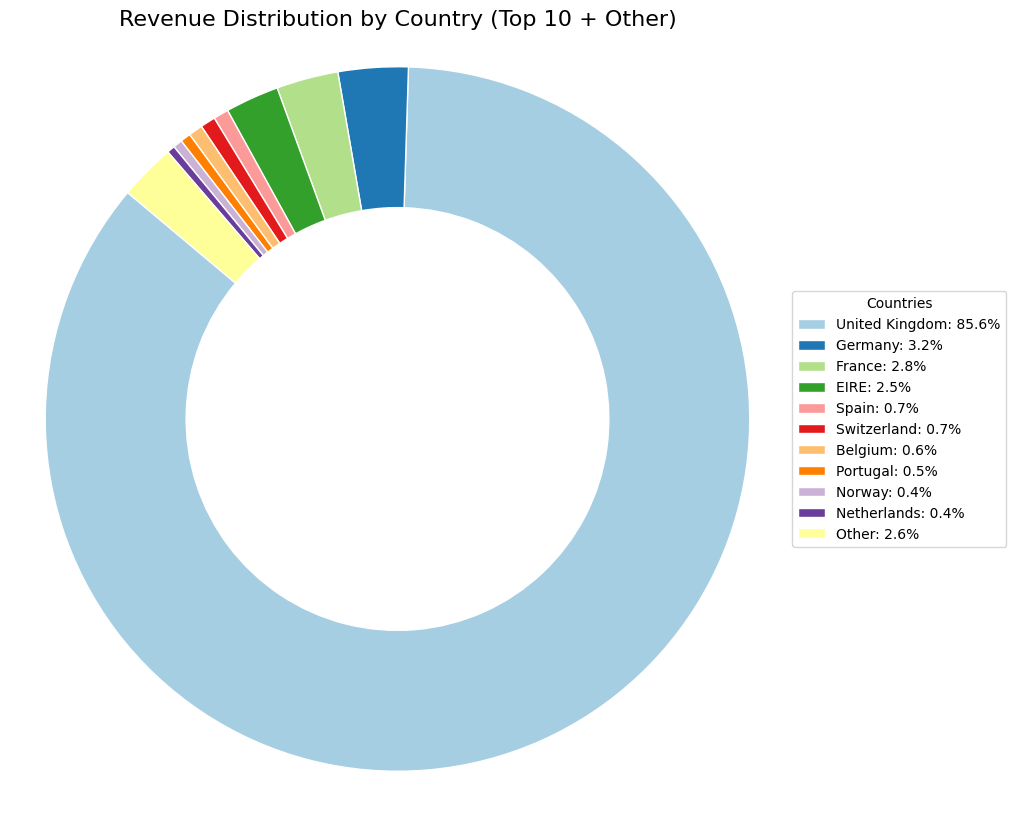

In [43]:
# 4. Region/  country trends

country_sales = (
    df_cleaned.groupby('Country')['GrossRevenue']
      .sum()
      .sort_values(ascending=False)
)

# Select the top 10 countries and group the rest as: Other
top_10_countries = country_sales.head(10)
other_countries_revenue = country_sales.iloc[10:].sum()

pie_data = pd.concat([top_10_countries, pd.Series({'Other': other_countries_revenue})])

plt.figure(figsize=(10, 10))
wedges, texts = plt.pie(
    pie_data,
    startangle=140,
    colors=sns.color_palette('Paired', len(pie_data)),
    wedgeprops=dict(width=0.4, edgecolor='w') # Added for better visual separation
)

plt.title('Revenue Distribution by Country (Top 10 + Other)', fontsize=16)
plt.axis('equal') # Equal aspect ratio that pie is drawn as a circle.

legend_labels = [f'{idx}: {val:.1f}%' for idx, val in zip(pie_data.index, pie_data / pie_data.sum() * 100)]
plt.legend(wedges, legend_labels, title="Countries", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

# TOP AND BOTTOM PERFORMERS

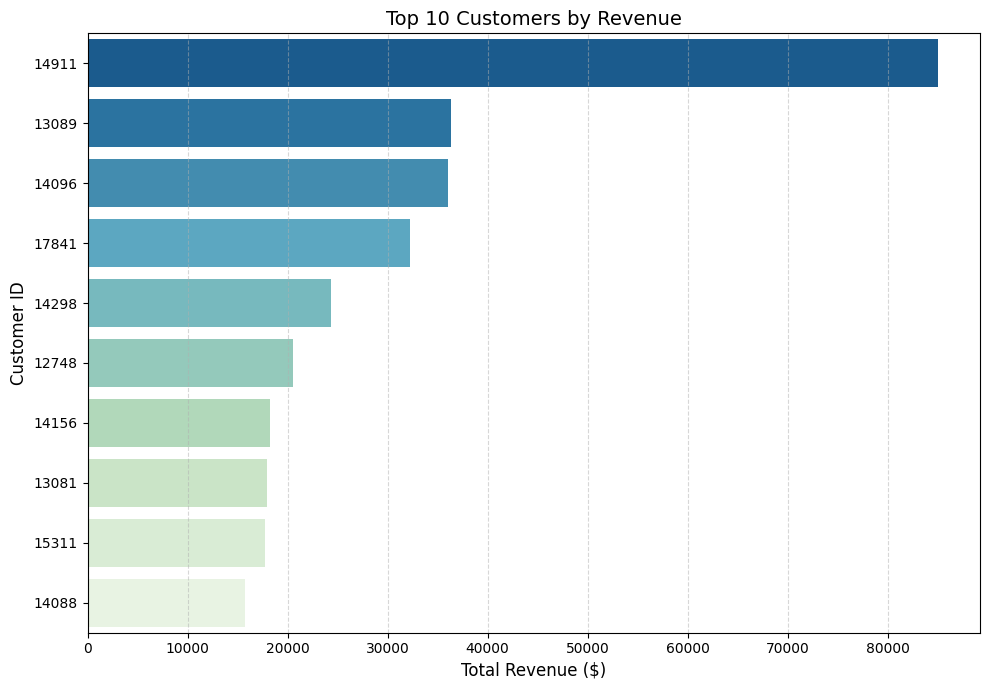

In [44]:
# TOP CUSTOMERS
top_customers = (
    df_cleaned[df_cleaned['CustomerID'] != 99999].groupby('CustomerID')['GrossRevenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# BOTTOM CUSTOMERS
bottom_customers = (
    df_cleaned[df_cleaned['CustomerID'] != 99999].groupby('CustomerID')['GrossRevenue']
      .sum()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette='GnBu_r', hue=top_customers.index.astype(str), legend=False)
plt.title('Top 10 Customers by Revenue', fontsize=14)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Time- based patterns

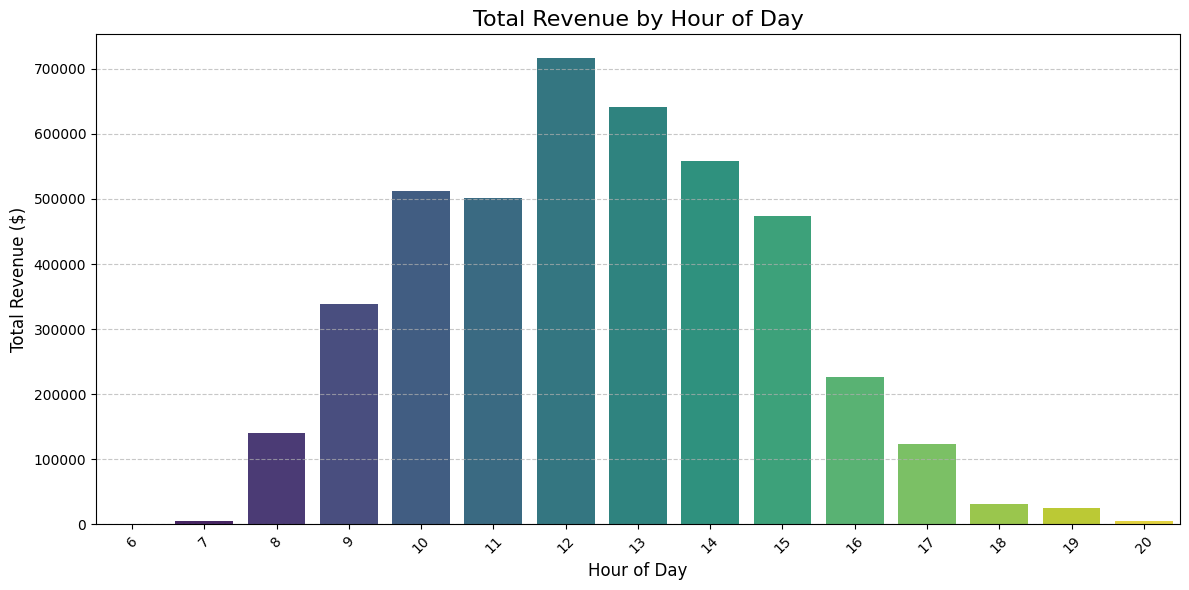

In [45]:
df_cleaned['Hour'] = df_cleaned['InvoiceDate'].dt.hour
hourly_sales = (
    df_cleaned.groupby('Hour')['GrossRevenue'].sum()
)

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_sales.index, y=hourly_sales.values, palette='viridis', hue=hourly_sales.index, legend=False)
plt.title('Total Revenue by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# WEEK 3

## BUSINESS ANALYSIS

## 1. CUSTOMER SEGMENTATION / CAMPAIGN

Customer DataFrame with assigned clusters (K-Means):
   CustomerID  Total_Revenue  Total_Orders  Total_Quantity  Total_Revenue_log  \
0       12347        3314.73             7            1893           8.106433   
1       12348          90.20             3             140           4.513055   
2       12349         999.15             1             523           6.907905   
3       12350         294.40             1             196           5.688330   
4       12352        1130.94             8             437           7.031688   

   Total_Orders_log  Total_Quantity_log  Cluster  
0          2.079442            7.546446        0  
1          1.386294            4.948760        1  
2          0.693147            6.261492        2  
3          0.693147            5.283204        2  
4          2.197225            6.082219        0  

Cluster Centroids (Original Scale - for interpretation):


,Cluster_ID,Total_Revenue,Total_Orders,Total_Quantity
0,0,2077.743704,9.066725,1192.012761
1,1,92.953747,1.244046,49.223846
2,2,472.237855,2.323009,280.246507



K-Means Clustering complete. Sample with new classification:


,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,Cluster,KMeans_Class
0,12347,3314.73,7,1893,0,High Value
1,12348,90.20,3,140,1,Low Value
2,12349,999.15,1,523,2,Medium Value
3,12350,294.40,1,196,2,Medium Value
4,12352,1130.94,8,437,0,High Value



Customer count by K-Means Class:
KMeans_Class
Medium Value    1933
High Value      1144
Low Value       1144
Name: count, dtype: int64


/tmp/ipykernel_606/3004945654.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='KMeans_Class', data=customer_df, order=['Low Value', 'Medium Value', 'High Value'], palette='cividis')


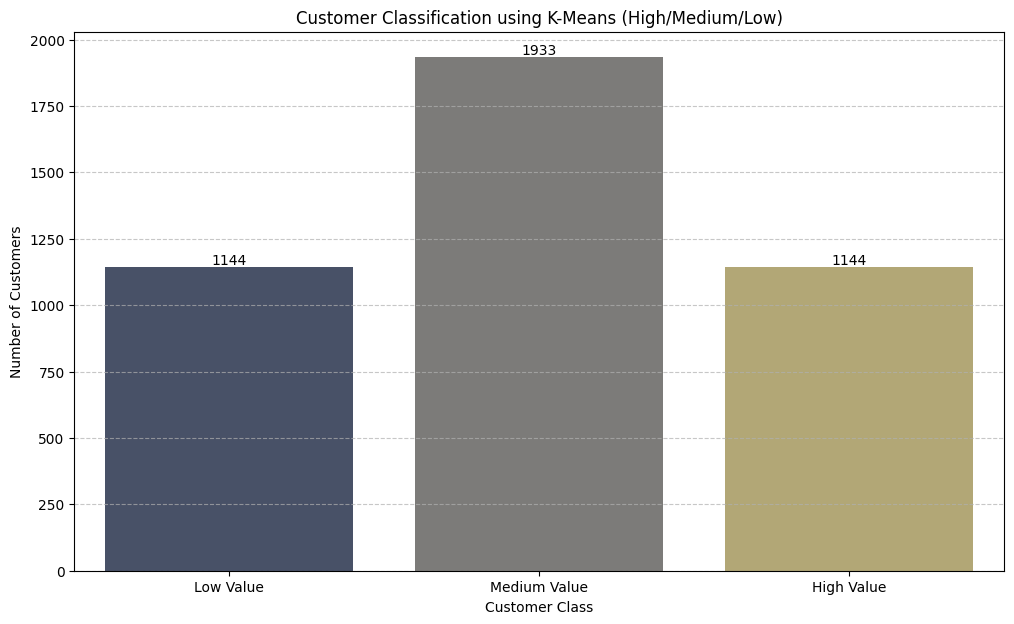

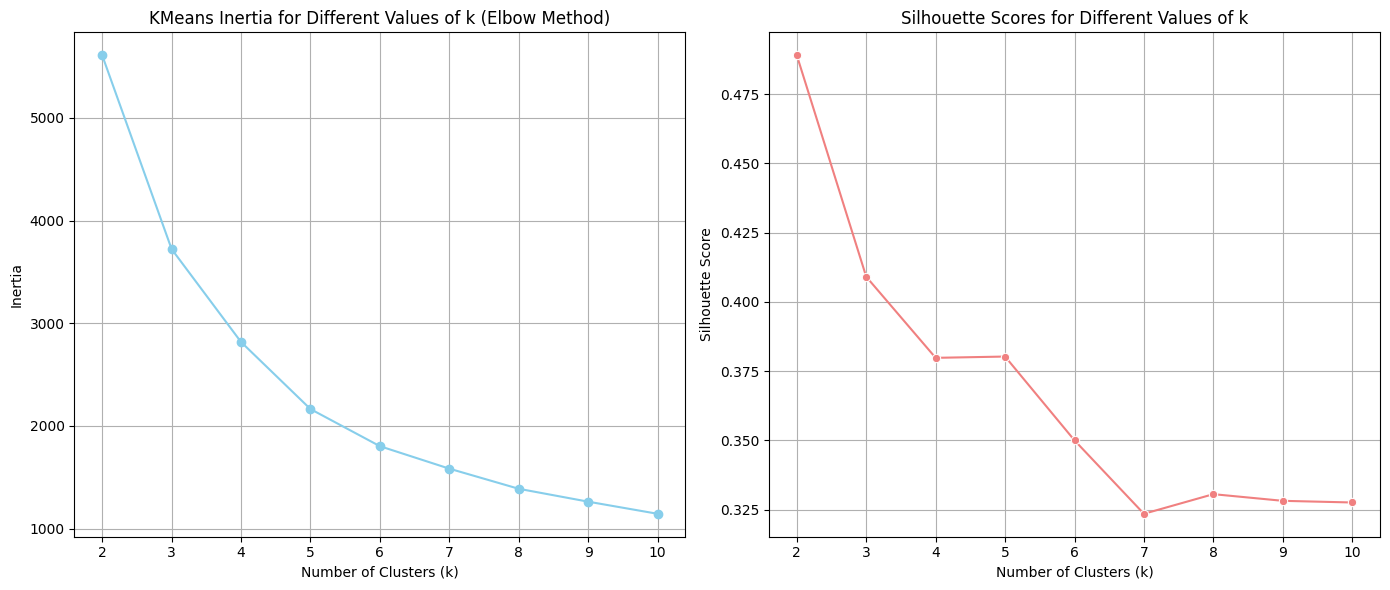

In [46]:
# CUSTOMER SEGMENTATION

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out the imputed CustomerID (99999) before aggregation - Note: df_cleaned already handled this.
# Using df_cleaned and 'GrossRevenue' for positive sales analysis
customer_df = df_cleaned.groupby('CustomerID').agg({
    'GrossRevenue':'sum',
    'InvoiceNo':'nunique',
    'Quantity':'sum'
}).reset_index()

customer_df.columns = [
    'CustomerID',
    'Total_Revenue',
    'Total_Orders',
    'Total_Quantity'
]

# Ensure 'Total_Quantity' is non-negative before applying log transformation
customer_df['Total_Quantity'] = np.maximum(0, customer_df['Total_Quantity'])

# Apply log transformation to reduce skewness and handle outliers
customer_df['Total_Revenue_log'] = np.log1p(customer_df['Total_Revenue'])
customer_df['Total_Orders_log'] = np.log1p(customer_df['Total_Orders'])
customer_df['Total_Quantity_log'] = np.log1p(customer_df['Total_Quantity'])

# 1. Select relevant features for clustering (log-transformed features)
features = customer_df[['Total_Revenue_log', 'Total_Orders_log', 'Total_Quantity_log']]

# 2. Scale the features using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Apply KMeans clustering with 3 clusters (High, Medium, Low)
n_clusters = 3

# init='k-means++' is used for smart initialization of centroids ;
# n_init='auto' handles multiple initializations to find the best centroids;
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init='auto')
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

print("Customer DataFrame with assigned clusters (K-Means):")
print(customer_df.head())

# Analyze cluster centroids to define High/Medium/Low
# We need the cluster centroids in original scale to interpret them
cluster_centers_original_scale = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                             columns=['Total_Revenue_log', 'Total_Orders_log', 'Total_Quantity_log'])
cluster_centers_original_scale['Cluster_ID'] = cluster_centers_original_scale.index

# To interpret, convert log-transformed centroids back to original scale (for reporting purposes)
cluster_centers_original_scale['Total_Revenue'] = np.expm1(cluster_centers_original_scale['Total_Revenue_log'])
cluster_centers_original_scale['Total_Orders'] = np.expm1(cluster_centers_original_scale['Total_Orders_log'])
cluster_centers_original_scale['Total_Quantity'] = np.expm1(cluster_centers_original_scale['Total_Quantity_log'])

print("\nCluster Centroids (Original Scale - for interpretation):")
display(cluster_centers_original_scale[['Cluster_ID', 'Total_Revenue', 'Total_Orders', 'Total_Quantity']])

# Sort clusters based on 'Total_Revenue' to assign High/Medium/Low labels
# Higher Total_Revenue typically means 'High Value'
cluster_order = cluster_centers_original_scale.sort_values(by='Total_Revenue', ascending=True)['Cluster_ID'].tolist()

# Create a mapping from Cluster ID to High/Medium/Low
# Assuming 3 clusters, ordered from lowest to highest revenue
cluster_map = {cluster_order[0]: 'Low Value',
               cluster_order[1]: 'Medium Value',
               cluster_order[2]: 'High Value'}

customer_df['KMeans_Class'] = customer_df['Cluster'].map(cluster_map)

print("\nK-Means Clustering complete. Sample with new classification:")
display(customer_df[['CustomerID', 'Total_Revenue', 'Total_Orders', 'Total_Quantity', 'Cluster', 'KMeans_Class']].head())

print("\nCustomer count by K-Means Class:")
print(customer_df['KMeans_Class'].value_counts())

# Visualize K-Means customer classes
plt.figure(figsize=(12, 7)) # Increased figure size for better visibility
ax = sns.countplot(x='KMeans_Class', data=customer_df, order=['Low Value', 'Medium Value', 'High Value'], palette='cividis')
plt.title('Customer Classification using K-Means (High/Medium/Low)')
plt.xlabel('Customer Class')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels to the bars, adjusting position for small bars
for p in ax.patches:
    height = p.get_height()
    # Adjust label position for very small bars
    if height < 10: # If the bar is very small, place label a bit higher
        ax.text(p.get_x() + p.get_width() / 2.,
                height + 50, # Place the text 50 units above the bar for visibility
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, color='black')
    else:
        # For larger bars, place label just above the bar
        ax.text(p.get_x() + p.get_width() / 2.,
                height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()

# Evaluate KMeans for different k values using Inertia and Silhouette Score
inertia = []
silhouette_scores = []
k_range = range(2, 11) # Test k from 2 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    if k > 1: # Silhouette score requires at least 2 clusters
        score = silhouette_score(scaled_features, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None) # Not strictly needed as k_range starts from 2, but good for robustness

# Plot KMeans Inertia (Elbow Method)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linestyle='-', color='skyblue')
plt.title('KMeans Inertia for Different Values of k (Elbow Method)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
# Filter out None if k_range started from 1 and silhouette_scores[0] was None
sns.lineplot(x=list(k_range), y=silhouette_scores, marker='o', color='lightcoral')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

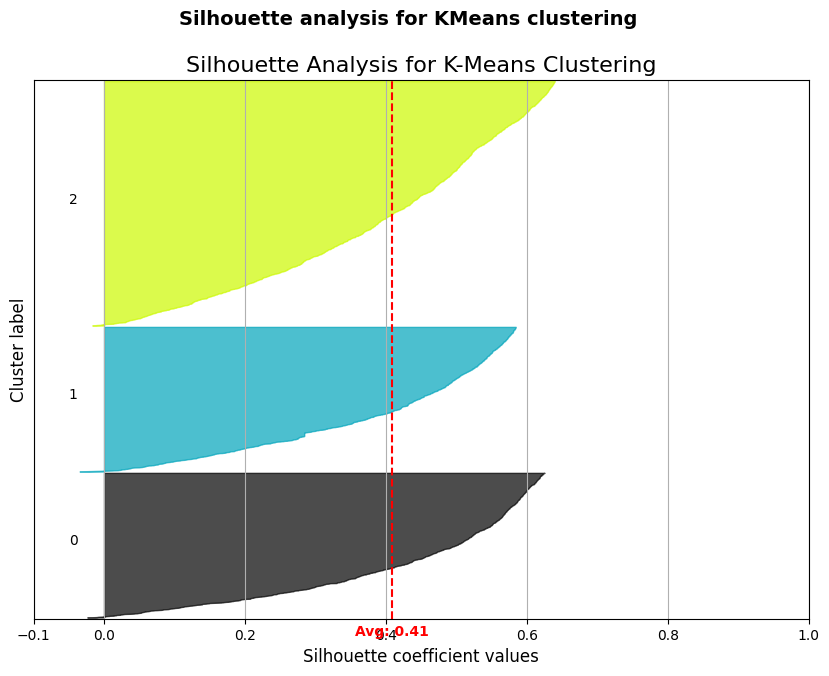

In [47]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# Calculate the Silhouette Score for the 3-cluster K-Means model
silhouette_avg = silhouette_score(scaled_features, customer_df['Cluster'])

# Create a subplot with 1 row and 2 columns
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))

# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all
# values are positive
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to make them appear distinctly separate.
ax1.set_ylim([0, len(scaled_features) + (n_clusters + 1) * 10])

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(scaled_features, customer_df['Cluster'])

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = \
        sample_silhouette_values[customer_df['Cluster'] == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette Analysis for K-Means Clustering", fontsize=16)
ax1.set_xlabel("Silhouette coefficient values", fontsize=12)
ax1.set_ylabel("Cluster label", fontsize=12)

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

# Add the silhouette_avg score as text below the line
ax1.text(silhouette_avg, -50, f'Avg: {silhouette_avg:.2f}', color='red', ha='center', va='top', fontsize=10, fontweight='bold')

ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle(
    ("Silhouette analysis for KMeans clustering"),
    fontsize=14, fontweight='bold'
)
plt.grid()
plt.show()

In [48]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Total_Revenue', y='Total_Orders', hue='KMeans_Class', data=plot_df, palette=class_colors, s=100, alpha=0.7)
plt.title('2D K-Means Clustering of Customers: Revenue vs. Orders', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Customer Class')
plt.tight_layout()
plt.show()

NameError: name 'plot_df' is not defined

<Figure size 1000x800 with 0 Axes>

In [49]:
import plotly.express as px
import numpy as np

# Prepare data for 3D plot
plot_df = customer_df.copy()

# Trim outliers for visualization: filter out the top 1% of values for each metric
# This helps in visualizing the bulk of the data more clearly
for col in ['Total_Revenue', 'Total_Orders', 'Total_Quantity']:
    upper_bound = plot_df[col].quantile(0.99)
    plot_df = plot_df[plot_df[col] <= upper_bound]

# Map KMeans_Class to numerical values for consistent coloring if needed, or use directly with hue in some plotting libraries
# For plotly, we can directly use the 'KMeans_Class' column for coloring.
class_colors = {'Low Value': 'blue', 'Medium Value': 'green', 'High Value': 'red'}

fig = px.scatter_3d(plot_df,
                    x='Total_Revenue',
                    y='Total_Orders',
                    z='Total_Quantity',
                    color='KMeans_Class',
                    color_discrete_map=class_colors, # Use the defined color map
                    title='Interactive 3D K-Means Clustering of Customers (Top 1% Outliers Removed)',
                    labels={'Total_Revenue': 'Total Revenue',
                            'Total_Orders': 'Total Orders',
                            'Total_Quantity': 'Total Quantity'},
                    height=700) # Adjust height for better viewing

fig.update_layout(scene=dict(
    xaxis_title='Total Revenue',
    yaxis_title='Total Orders',
    zaxis_title='Total Quantity',
    # Adjust camera eye to simulate a 'backward view'
    camera=dict(
        eye=dict(x=-1.5, y=-1.5, z=1)  # Example: looking from 'behind' and slightly 'below'/'left' the default
    )
))

fig.show()

## K-Means Customer Segmentation Summary

We performed K-Means clustering on three key customer metrics: **Total Revenue**, **Total Orders**, and **Total Quantity**. To handle the skewed distribution of these metrics and reduce the impact of outliers, a logarithmic transformation (`np.log1p`) was applied, followed by feature scaling using `StandardScaler`.

The clustering identified three distinct customer segments: **Low Value**, **Medium Value**, and **High Value**. The 3D plot (with the top 1% of extreme outliers removed for better visibility) effectively illustrates the separation and density of these clusters.

### Segment Characteristics and Targeted Marketing Strategies

Below are the average characteristics for each customer segment, derived from their cluster centroids, along with tailored marketing recommendations:

**1. Low Value Customers**
- **Average Total Revenue**: ~$88.61
- **Average Total Orders**: ~1.26
- **Average Total Quantity**: ~49.71

These customers have made very few purchases, spent little, and have low engagement. They might be one-time buyers or new customers who haven't fully engaged.

**Marketing Strategies:**
- **Re-engagement Campaigns**: Send targeted email campaigns with attractive offers (e.g., discounts on their first repeat purchase, free shipping) to encourage a second purchase. Highlight popular products or new arrivals.
- **Educational Content**: Provide content that showcases the value and breadth of your product offerings. This could include product tutorials, lifestyle content, or customer testimonials to build interest and trust.

**2. Medium Value Customers**
- **Average Total Revenue**: ~$452.62
- **Average Total Orders**: ~2.34
- **Average Total Quantity**: ~285.79

These customers show moderate engagement, having made a few purchases with a reasonable spend. They have the potential to become more loyal with the right nurturing.

**Marketing Strategies:**
- **Loyalty Program Enrollment**: Introduce and incentivize participation in a loyalty program to reward their existing behavior and encourage continued purchases. Offer exclusive previews or early access to sales.
- **Personalized Recommendations**: Use their purchase history to provide highly personalized product recommendations, cross-sells, or upsells. Focus on products that complement their previous purchases or align with their interests.

**3. High Value Customers**
- **Average Total Revenue**: ~$1946.17
- **Average Total Orders**: ~9.01
- **Average Total Quantity**: ~1187.52

These are your most valuable customers, characterized by high spending, frequent purchases, and large order quantities. They are crucial for your business's sustained success.

**Marketing Strategies:**
- **VIP Treatment & Exclusivity**: Offer exclusive benefits such as dedicated customer support, special VIP discounts, invitations to private sales, or gifts. Make them feel appreciated and valued.
- **Referral Programs**: Encourage them to refer new customers by offering generous incentives for both the referrer and the referred. Leverage their satisfaction and loyalty to expand your customer base organically.

In [50]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for the 3-cluster K-Means model
silhouette_avg = silhouette_score(scaled_features, kmeans.labels_)

print(f"Silhouette Score for 3-cluster K-Means model: {silhouette_avg:.4f}")

# Show the size (count of customers) of each cluster
print("\nCustomer count by Cluster ID:")
print(customer_df['Cluster'].value_counts().sort_index())

Silhouette Score for 3-cluster K-Means model: 0.3275

Customer count by Cluster ID:
Cluster
0    1144
1    1144
2    1933
Name: count, dtype: int64


## RFM ANALYSIS

OUTLIER CHECKING AND CLEANING FOR RFM

Removed 132 outliers from 'Recency'. Remaining rows: 4059
Removed 238 outliers from 'Frequency'. Remaining rows: 3821
Removed 283 outliers from 'Monetary'. Remaining rows: 3538

RFM Analysis DataFrame after outlier removal (first 5 rows):


,CustomerID,Recency,Frequency,Monetary
1,12348,249,3,90.20
2,12349,19,1,999.15
3,12350,310,1,294.40
4,12352,36,7,1130.94
5,12353,204,1,29.30


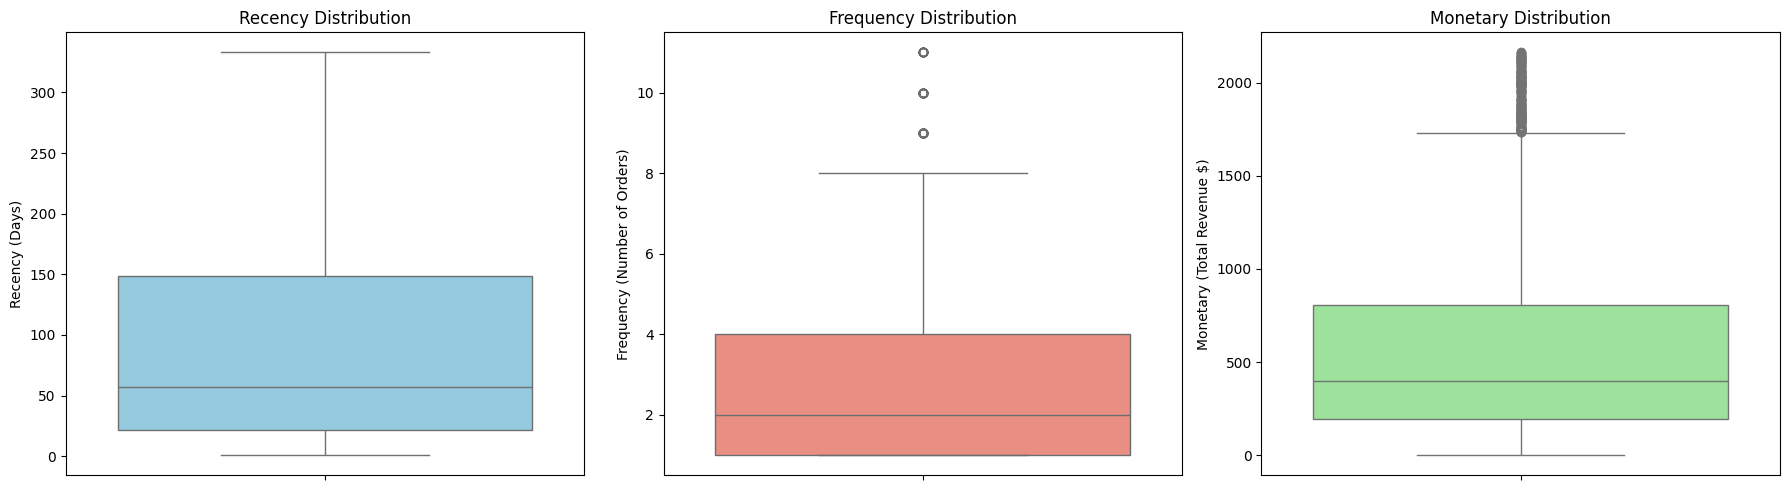

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt # Added import for datetime

# Re-create rfm_analysis to ensure it's defined
rfm_df = df_cleaned.copy()

# Remove 'C' cancelled orders from df
rfm_df = rfm_df[~rfm_df['InvoiceNo'].astype(str).str.startswith('C')]

# Define a snapshot date for recency calculation (one day after the last transaction in the dataset)
snapshot_date = rfm_df['InvoiceDate'].max() + dt.timedelta(days=1);

# Group by CustomerID and calculate RFM metrics
rfm_analysis = rfm_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency: Days since last purchase
    'InvoiceNo': lambda num: num.nunique(),                       # Frequency: Number of unique orders
    'GrossRevenue': lambda price: price.sum()                           # Monetary: Total revenue
}).reset_index()

# Rename columns for clarity
rfm_analysis.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


# Function to remove outliers using IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Keep values within bounds. Ensure lower bound is not negative for count-based metrics if it makes sense.
    return df[(df[column] >= max(0, lower_bound)) & (df[column] <= upper_bound)]

# Apply outlier removal to RFM metrics
rfm_no_outliers = rfm_analysis.copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    initial_rows = len(rfm_no_outliers)
    rfm_no_outliers = remove_outliers_iqr(rfm_no_outliers, col)
    rows_removed = initial_rows - len(rfm_no_outliers)
    print(f"Removed {rows_removed} outliers from '{col}'. Remaining rows: {len(rfm_no_outliers)}")

print("\nRFM Analysis DataFrame after outlier removal (first 5 rows):")
display(rfm_no_outliers.head())

# Plotting distributions after outlier removal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfm_no_outliers['Recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution')
axes[0].set_ylabel('Recency (Days)')

sns.boxplot(y=rfm_no_outliers['Frequency'], ax=axes[1], color='salmon')
axes[1].set_title('Frequency Distribution')
axes[1].set_ylabel('Frequency (Number of Orders)')

sns.boxplot(y=rfm_no_outliers['Monetary'], ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Distribution')
axes[2].set_ylabel('Monetary (Total Revenue $)')

plt.tight_layout()
plt.show()

RFM CUSTOMER SEGMENTATION

RFM DataFrame created :


,CustomerID,Recency,Frequency,Monetary
0,12347,2,7,3243.33
1,12348,249,3,90.20
2,12349,19,1,918.10
3,12350,310,1,294.40
4,12352,36,8,986.34



RFM Segmentation complete. Sample of segmented customers:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,R_Score_int,F_Score_int,M_Score_int,Total_RFM_Score,RFM_Level
0,12347,2,7,3243.33,5,4,5,545,5,4,5,14,Champions
1,12348,249,3,90.20,1,2,1,121,1,2,1,4,At Risk
2,12349,19,1,918.10,4,1,4,414,4,1,4,9,Loyal Customers
3,12350,310,1,294.40,1,1,2,112,1,1,2,4,At Risk
4,12352,36,8,986.34,3,4,4,344,3,4,4,11,Loyal Customers



Customer count by RFM Segment:
RFM_Level
Potential Loyalists    1224
Champions               895
Loyal Customers         878
At Risk                 861
Lost Customers          350
Name: count, dtype: int64


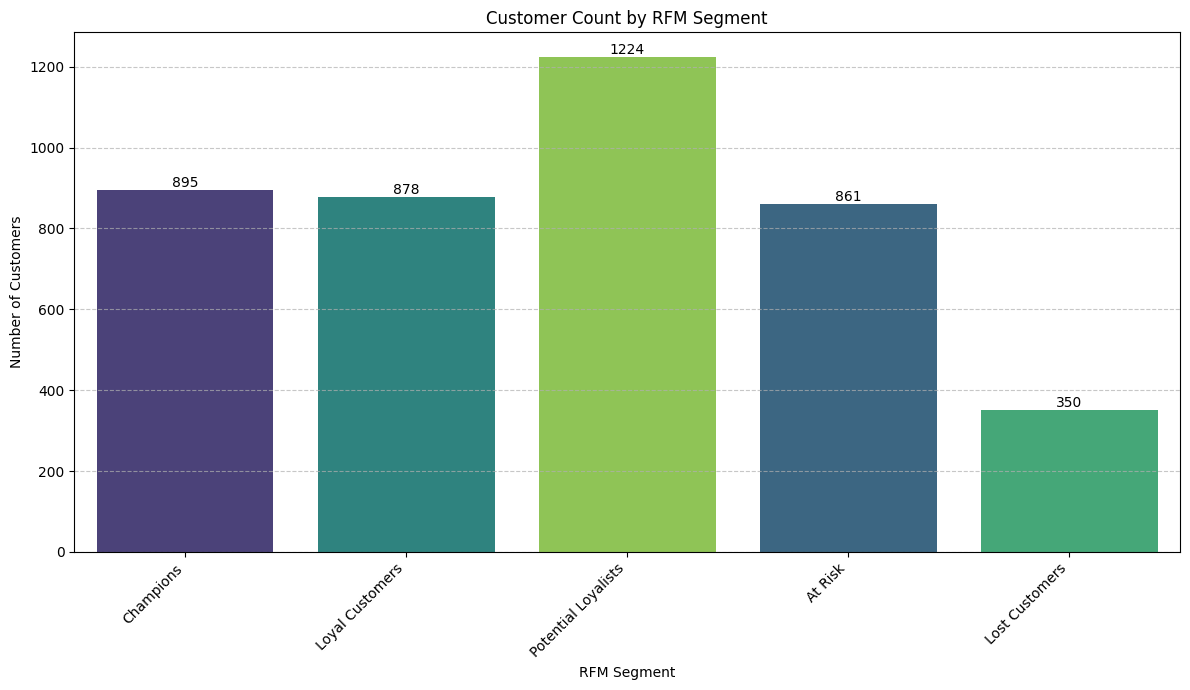

In [52]:
import datetime as dt

# Apply IQR-based outlier removal for 'Quantity' and 'UnitPrice'
# For Quantity:
Q1_qty = df_cleaned['Quantity'].quantile(0.25)
Q3_qty = df_cleaned['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
upper_qty = Q3_qty + 1.5 * IQR_qty
lower_qty = Q1_qty - 1.5 * IQR_qty

# For UnitPrice:
Q1_price = df_cleaned['UnitPrice'].quantile(0.25)
Q3_price = df_cleaned['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_price = Q3_price + 1.5 * IQR_price
lower_price = Q1_price - 1.5 * IQR_price

df_cleaned = df_cleaned[
    (df_cleaned['Quantity'] >= lower_qty) & (df_cleaned['Quantity'] <= upper_qty) &
    (df_cleaned['UnitPrice'] >= lower_price) & (df_cleaned['UnitPrice'] <= upper_price)
].copy()

df_cleaned['IsReturn'] = df_cleaned['Quantity'] < 0
df_cleaned['GrossRevenue'] = df_cleaned['Revenue'].apply(lambda x: x if x > 0 else 0)

# Calculate Recency, Frequency, Monetary (RFM)
# Set a snapshot date for recency calculation (one day after the last transaction in the dataset)
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'InvoiceNo': lambda num: num.nunique(),                       # Frequency
    'GrossRevenue': lambda price: price.sum()                      # Monetary
})

# Rename the columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Reset index to make CustomerID a column
rfm = rfm.reset_index()

print("RFM DataFrame created :")
display(rfm.head())

# --- Segmenting Customers with RFM ---

# Helper function to create qcut scores dynamically assigns scores from 1 to q.
def create_qcut_score(series, q, ascending_labels=True):
    # First, get the bins. `duplicates='drop'` might result in fewer than `q` unique bins.
    # We don't provide labels here to let qcut determine the actual number of bins.
    _, bins = pd.qcut(series, q, retbins=True, duplicates='drop')

    num_actual_bins = len(bins) - 1

    # If no bins can be formed (e.g., all values are identical), assign a default score
    if num_actual_bins == 0:
        return pd.Series(1, index=series.index, dtype='category') # Assign a default score of 1

    # Create labels based on the actual number of bins created
    if ascending_labels:
        labels = list(range(1, num_actual_bins + 1))
    else:
        labels = list(range(num_actual_bins, 0, -1))

    # Apply qcut with the dynamically generated labels
    return pd.qcut(series, q, labels=labels, duplicates='drop')

# Create RFM scores using the helper function with 5 quantiles
# Recency: Lower value is better, so assign higher score to lower recency
rfm['R_Score'] = create_qcut_score(rfm['Recency'], 5, ascending_labels=False)
# Frequency: Higher value is better
rfm['F_Score'] = create_qcut_score(rfm['Frequency'], 5, ascending_labels=True)
# Monetary: Higher value is better
rfm['M_Score'] = create_qcut_score(rfm['Monetary'], 5, ascending_labels=True)

# Combine RFM scores (string representation)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Calculate a total RFM score by summing individual scores
rfm['R_Score_int'] = rfm['R_Score'].astype(int)
rfm['F_Score_int'] = rfm['F_Score'].astype(int)
rfm['M_Score_int'] = rfm['M_Score'].astype(int)
rfm['Total_RFM_Score'] = rfm['R_Score_int'] + rfm['F_Score_int'] + rfm['M_Score_int']

# Define RFM segments based on Total_RFM_Score ranges
def assign_rfm_segment_by_total_score(total_score):
    if total_score >= 12: # Champions: High R, F, M scores (e.g., 5-4-3 or better)
        return 'Champions'
    elif total_score >= 9: # Loyal Customers: Good R, F, M scores (e.g., 4-3-2 or better)
        return 'Loyal Customers'
    elif total_score >= 6: # Potential Loyalists: Moderate R, F, M scores (e.g., 3-2-1 or better)
        return 'Potential Loyalists'
    elif total_score >= 4: # At Risk: Lower R, F, M scores (e.g., 2-1-1 or better)
        return 'At Risk'
    else: # Lost Customers: Lowest R, F, M scores (e.g., 1-1-1 or 1-1-2)
        return 'Lost Customers'

rfm['RFM_Level'] = rfm['Total_RFM_Score'].apply(assign_rfm_segment_by_total_score)

print("\nRFM Segmentation complete. Sample of segmented customers:")
display(rfm.head())

# Display the count of customers in each segment
print("\nCustomer count by RFM Segment:")
print(rfm['RFM_Level'].value_counts())

# Visualize RFM segments
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting
import seaborn as sns # Ensure seaborn is imported for plotting

plt.figure(figsize=(12, 7))
# Define the order of segments for plotting (all five explicitly)
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost Customers']
ax = sns.countplot(x='RFM_Level', data=rfm, palette='viridis', order=segment_order, hue='RFM_Level', legend=False)
plt.title('Customer Count by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better readability

# Add data labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Only add label if there are customers in the segment
        ax.text(p.get_x() + p.get_width() / 2.,
                height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

CUSTOMER CHURN RISK ANALYSIS

Customer count by Churn Risk Level:
Churn_Risk
Low Risk       1773
Medium Risk    1224
High Risk      1211
Name: count, dtype: int64


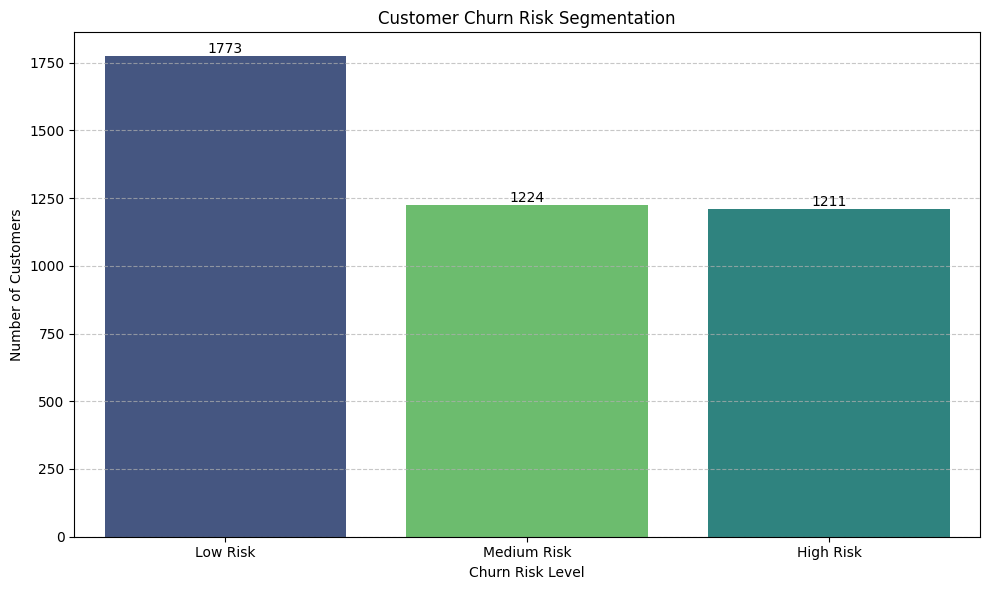


Average RFM Metrics by Churn Risk Level:


,Recency,Frequency,Monetary
Churn_Risk,,,
Low Risk,27.866892,8.485618,1831.585178
Medium Risk,73.946895,2.035948,396.754757
High Risk,205.233691,1.290669,160.918118


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perform churn risk analysis based on RFM levels

# Mapping RFM_Level to Churn Risk
# 'At Risk Customers' explicitly defined as having low Recency score (R_Score = 1)
# 'Other Segment' can be considered Medium Risk (not recent, not frequent, not high monetary, but not as bad as 'At Risk')
# 'Loyal Customers' and 'Champions' are Low Risk
def assign_churn_risk(rfm_level):
    # The RFM_Level column is now based on 5 quantiles and 5 segments.
    # Adjusting the churn risk mapping to align with the new RFM_Level definitions.
    if rfm_level == 'At Risk' or rfm_level == 'Lost Customers':
        return 'High Risk'
    elif rfm_level == 'Loyal Customers' or rfm_level == 'Champions':
        return 'Low Risk'
    else: # This covers 'Potential Loyalists'
        return 'Medium Risk'

rfm['Churn_Risk'] = rfm['RFM_Level'].apply(assign_churn_risk)

print("Customer count by Churn Risk Level:")
print(rfm['Churn_Risk'].value_counts())

# Visualize Churn Risk Segments
plt.figure(figsize=(10, 6))
churn_order = ['Low Risk', 'Medium Risk', 'High Risk']
sns.countplot(x='Churn_Risk', data=rfm, order=churn_order, palette='viridis', hue='Churn_Risk', legend=False)
plt.title('Customer Churn Risk Segmentation')
plt.xlabel('Churn Risk Level')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels to the bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2., height, f'{int(height)}',
                   ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# Display average RFM metrics for each churn risk group for deeper insight
churn_risk_summary = rfm.groupby('Churn_Risk')[['Recency', 'Frequency', 'Monetary']].mean().reindex(churn_order)
print("\nAverage RFM Metrics by Churn Risk Level:")
display(churn_risk_summary)

In [54]:
import pandas as pd
from google.colab import files

# Calculate Last Purchase Date for each customer from the cleaned data
last_purchase_date_df = df_cleaned.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase_date_df.rename(columns={'InvoiceDate': 'Last_Purchase_Date'}, inplace=True)

# Merge with the RFM DataFrame
customer_summary_df = pd.merge(rfm, last_purchase_date_df, on='CustomerID', how='left')

# Select and rename columns to match the user's request
customer_summary_df = customer_summary_df[[
    'CustomerID',
    'RFM_Level',  # Segment
    'RFM_Score',  # Combined RFM score
    'Recency',
    'Frequency',  # Total Orders
    'Monetary',   # Total Revenue
    'Churn_Risk',
    'Last_Purchase_Date'
]].copy()

customer_summary_df.rename(columns={
    'RFM_Level': 'Segment',
    'RFM_Score': 'RFM Score',
    'Frequency': 'Total Orders',
    'Monetary': 'Total Revenue',
    'Churn_Risk': 'Churn Risk',
    'Last_Purchase_Date': 'Last Purchase Date'
}, inplace=True)

print("Customer Analytics Summary Table created:")
display(customer_summary_df.head())

# Save the DataFrame to a CSV file
file_name = 'customer_analytics_summary.csv'
customer_summary_df.to_csv(file_name, index=False)

# Download the file
files.download(file_name)

print(f"\n'{file_name}' has been downloaded to your desktop.")

Customer Analytics Summary Table created:


,CustomerID,Segment,RFM Score,Recency,Total Orders,Total Revenue,Churn Risk,Last Purchase Date
0,12347,Champions,545,2,7,3243.33,Low Risk,2011-12-07 15:52:00
1,12348,At Risk,121,249,3,90.20,High Risk,2011-04-05 10:47:00
2,12349,Loyal Customers,414,19,1,918.10,Low Risk,2011-11-21 09:51:00
3,12350,At Risk,112,310,1,294.40,High Risk,2011-02-02 16:01:00
4,12352,Loyal Customers,344,36,8,986.34,Low Risk,2011-11-03 14:37:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


'customer_analytics_summary.csv' has been downloaded to your desktop.


REQUIREMENTS.txt

In [55]:
import subprocess
from google.colab import files

# Run pip freeze to get the list of installed packages
result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)

# Write the output to requirements.txt
requirements_content = result.stdout
file_name = 'requirements.txt'
with open(file_name, 'w') as f:
    f.write(requirements_content)

print(f"'{file_name}' has been created.")

# Download the file
files.download(file_name)

print(f"\n'{file_name}' has been downloaded to your desktop.")

'requirements.txt' has been created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


'requirements.txt' has been downloaded to your desktop.
